### Classification In Machine Learning
   Classification algorithms are supervised machine learning techniques used to categorize data into distinct, predefined classes or labels

In [242]:
import numpy as np
import pandas as pd
import seaborn as sns

In [243]:
df = pd.read_csv('diabetes.csv')

In [244]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [245]:
df.duplicated().sum()

0

In [246]:
x = df.drop(['Outcome'],axis=1)
y = df.Outcome

In [247]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.23,random_state=42)

In [248]:
x_train.shape,x_test.shape,y_test.shape,y_test.shape

((591, 8), (177, 8), (177,), (177,))

In [249]:
x_train

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
745,12,100,84,33,105,30.0,0.488,46
165,6,104,74,18,156,29.9,0.722,41
164,0,131,88,0,0,31.6,0.743,32
28,13,145,82,19,110,22.2,0.245,57
608,0,152,82,39,272,41.5,0.270,27
...,...,...,...,...,...,...,...,...
71,5,139,64,35,140,28.6,0.411,26
106,1,96,122,0,0,22.4,0.207,27
270,10,101,86,37,0,45.6,1.136,38
435,0,141,0,0,0,42.4,0.205,29


In [250]:
from sklearn.linear_model import LogisticRegression

In [251]:
lr = LogisticRegression()

In [252]:
import warnings
warnings.filterwarnings('ignore')

In [253]:
lr.fit(x_train,y_train)

LogisticRegression()

### Perfomance Evaluation
    In refreesion we used r2 score and mean absolute error to evaluate perfomance but in classification we will do something like this

In [254]:
from sklearn.metrics import confusion_matrix, recall_score, f1_score,accuracy_score,precision_score,classification_report

In [255]:
lr.predict(x_train)

array([0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1,
       1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0,
       1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0,

In [256]:
y_pred_train = lr.predict(x_train)

In [257]:
comparison = pd.DataFrame({
    "Actual": y_train.values,
    "Predicted": y_pred_train
})

comparison.head()


,Actual,Predicted
0,0,0
1,1,0
2,1,0
3,0,0
4,0,1


In [258]:
accuracy_score(y_train,y_pred_train)

0.7834179357021996

In [259]:
confusion_matrix(y_train,y_pred_train)

array([[345,  41],
       [ 87, 118]], dtype=int64)

In [260]:
# tp  fp
# fn  tn

In [261]:
print(classification_report(y_train,y_pred_train))

              precision    recall  f1-score   support

           0       0.80      0.89      0.84       386
           1       0.74      0.58      0.65       205

    accuracy                           0.78       591
   macro avg       0.77      0.73      0.75       591
weighted avg       0.78      0.78      0.78       591



In [262]:
print(classification_report(y_train,y_pred_train))

              precision    recall  f1-score   support

           0       0.80      0.89      0.84       386
           1       0.74      0.58      0.65       205

    accuracy                           0.78       591
   macro avg       0.77      0.73      0.75       591
weighted avg       0.78      0.78      0.78       591



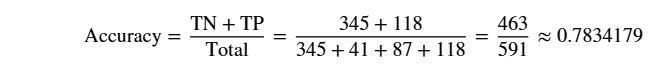

1. TN (True Negative)Your definition: "how many times we had zero"The Correction: It is specifically how many times the actual value was 0 AND the model correctly predicted 0.Your data: 345 times.2. FP (False Positive) — Type 1 ErrorYour definition: "how many times our model predicted 0 which was wrong"The Correction: This is reversed. A False Positive means the model predicted 1 (Positive), but it was wrong (actual value was 0).Your data: 41 times.3. FN (False Negative) — Type 2 ErrorYour definition: "how many times 1 was predicted 0"The Correction: Spot on! This is exactly right. The actual value was 1, but the model missed it and predicted 0.Your data: 87 times.4. TP (True Positive)Your definition: "how many times our model predicted 1"The Correction: Close, but it is specifically how many times the model predicted 1 AND it was correct (actual value was 1).Your data: 118 times.

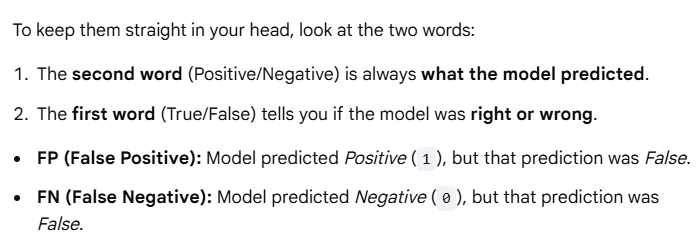

In [263]:
df.Outcome.value_counts()

0    500
1    268
Name: Outcome, dtype: int64

In [264]:
shuffle=df[df.Outcome==1].sample(268)

In [265]:
shuffle2=df[df.Outcome==0].sample(268)

In [266]:
balanced_data = pd.concat([shuffle,shuffle2]).sample(536)

In [267]:
balanced_data.Outcome.value_counts()

1    268
0    268
Name: Outcome, dtype: int64

In [268]:
balanced_data


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
579,2,197,70,99,0,34.7,0.575,62,1
297,0,126,84,29,215,30.7,0.520,24,0
671,1,99,58,10,0,25.4,0.551,21,0
520,2,68,70,32,66,25.0,0.187,25,0
638,7,97,76,32,91,40.9,0.871,32,1
...,...,...,...,...,...,...,...,...,...
151,4,114,65,0,0,21.9,0.432,37,0
702,1,168,88,29,0,35.0,0.905,52,1
386,5,116,74,29,0,32.3,0.660,35,1
375,12,140,82,43,325,39.2,0.528,58,1


In [269]:
# did this because our data was unbalanced thats the sole reason we balanced the data to improve our accuracy
x = balanced_data.drop('Outcome',axis=1)
y = balanced_data['Outcome']


In [270]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.23,random_state=42)

In [271]:
lr = LogisticRegression()
lr.fit(x_train,y_train)

LogisticRegression()

In [272]:
lr.predict(x_train)
y_pred_train = lr.predict(x_train)
comparison = pd.DataFrame({
    "Actual": y_train.values,
    "Predicted": y_pred_train
})

comparison.head()

,Actual,Predicted
0,1,1
1,0,1
2,0,1
3,0,1
4,1,1


In [273]:
accuracy_score(y_train,y_pred_train)

0.7742718446601942

In [274]:
confusion_matrix(y_train,y_pred_train)

array([[150,  44],
       [ 49, 169]], dtype=int64)

In [275]:
print(classification_report(y_train,y_pred_train))

              precision    recall  f1-score   support

           0       0.75      0.77      0.76       194
           1       0.79      0.78      0.78       218

    accuracy                           0.77       412
   macro avg       0.77      0.77      0.77       412
weighted avg       0.77      0.77      0.77       412

